# TP2

* Aballay, Cristian - SIU A2301
* Gianotti, Leandro - SIU D0161
* Mancini, Leonardo - SIU I0511

In [1]:
from pathlib import Path

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import json
import math

# Configuración básica
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## Objetivo

Implementar un detector de máximo enfoque sobre un video aplicando **técnicas de análisis espectral** similar al que utilizan las cámaras digitales modernas. El video a procesar será: **`focus_video.mov`**.

1. Se debe implementar un algoritmo que, dada una imagen o región, calcule la métrica propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"* y realizar dos experimentos:

   1. Medición sobre todo el frame.
   2. Medición sobre una ROI ubicada en el centro del frame. Área de la ROI = 5 o 10% del área total del frame.

Para cada experimento se debe presentar:

- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuándo el algoritmo detecta la región de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

## Image Sharpness Measure for Blurred Images in Frequency Domain

### 3. Proposed Algorithm for calculating Image Quality measure

#### 3.1 Algorithm for image quality measure

**Input:** Image $I$ of size $M \times N$.

**Output:** Image Quality measure (FM) where $FM$ stands for Frequency Domain Image Blur Measure.

**Step 1:** Compute $F$ which is the Fourier Transform representation of image $I$.

**Step 2:** Find $F_c$ which is obtained by shifting the origin of $F$ to centre.

**Step 3:** Calculate $AF = abs(F_c)$ where $AF$ is the absolute value of the centered Fourier transform of image $I$.

**Step 4:** Calculate $M = max(AF)$ where $M$ is the maximum value of the frequency component in $F$.

**Step 5:** Calculate $T_H$ = the total number of pixels in $F$ whose pixel value $> thres$, where:

$$
thres = \frac{M}{1000}
$$

**Step 6:** Calculate Image Quality measure (FM) from equation (1).

$$
\text{Image Quality Measure (FM)} = \frac{T_H}{M \times N}
$$


### Función de cálculo de FM

In [2]:
def calcular_FM(imagen):
    """
    Calcula la Medida de Desenfoque de Imagen en el Dominio de la Frecuencia (FM) para una imagen en escala de grises.

    Esta función estima el desenfoque de la imagen analizando la distribución de componentes
    de alta frecuencia en el dominio de Fourier. Las imágenes más nítidas tienden a tener
    un contenido de alta frecuencia más significativo, lo que resulta en un valor FM más alto.

    Retornae el valor FM que representa la medida de desenfoque en el dominio de la frecuencia.
    """

    # Entrada: imagen en escala de grises de tamaño M×N.

    # Paso 1: Calcular F, la Transformada de Fourier 2D de la imagen de entrada.
    F = np.fft.fft2(imagen)

    # Paso 2: Desplazar la componente de frecuencia cero al centro del espectro.
    Fc = np.fft.fftshift(F)

    # Paso 3: Calcular el espectro de magnitud (valores absolutos de la FT centrada).
    AF = np.abs(Fc)

    # Paso 4: Encontrar la magnitud máxima en el dominio de la frecuencia.
    M = AF.max()

    # Paso 5: Contar componentes de frecuencia por encima de un umbral (thres = M/1000).
    thres = M / 1000.0
    #TH = int((AF > thres).sum())
    TH = np.sum(AF > thres)

    # Paso 6: Calcular la Medida de Desenfoque de Imagen en el Dominio de la Frecuencia (FM).
    # FM = TH / (M * N), donde M*N es el número total de píxeles.
    M_size = imagen.shape[0] * imagen.shape[1]
    FM = TH / M_size

    # Salida: valor FM que representa la medida de desenfoque en el dominio de la frecuencia.
    return FM

### Función de útiles de video, ROI y gráficos

In [3]:
PORCENTAJE_ROI = 0.10
NOMBRE_VIDEO = "focus_video.mov"

def obtener_roi(frame, porcentaje=PORCENTAJE_ROI):
    """
    Extrae una ROI cuadrada centrada. El lado se elige para que el área sea `porcentaje` del frame (por defecto, 10%).

    Retorna la región y la caja (x1, y1, x2, y2) en coordenadas del frame.
    """
    alto, ancho = frame.shape[:2]
    area = ancho * alto
    areaROI = porcentaje * area
    lado = int(np.sqrt(areaROI))

    # Esquina superior izquierda.
    x1 = max(ancho // 2 - lado // 2, 0)
    y1 = max(alto // 2 - lado // 2, 0)
    
    roi = frame[y1:y1 + lado, x1:x1 + lado]

    # Esquina inferior derecha.
    x2 = x1 + roi.shape[1]
    y2 = y1 + roi.shape[0]
    
    return roi, (x1, y1, x2, y2)

def leer_frame(numero_frame):
    """Lee un frame BGR por índice."""
    captura = cv.VideoCapture(str(NOMBRE_VIDEO))
    captura.set(cv.CAP_PROP_POS_FRAMES, int(numero_frame))
    ret, frame = captura.read()
    captura.release()
    if not ret:
        raise RuntimeError(f"No se pudo leer el frame {numero_frame}")
    return frame

def graficar_fm(frames, valores, deteccion, titulo, color="tab:blue", ax=None):
    """Dibuja FM por frame y marca el máximo que devolvió el detector."""

    ax.scatter(frames, valores, s=18, color=color, zorder=2)
    ax.axvspan(
        deteccion["frame_inicio"],
        deteccion["frame_fin"],
        color=color,
        alpha=0.15,
        zorder=0,
        label="zona de máximo enfoque",
    )
    ax.axvline(
        deteccion["frame_max"],
        color="black",
        linestyle="--",
        linewidth=1,
        zorder=1,
        label=f"máximo: frame {deteccion['frame_max']}",
    )
    ax.scatter(
        [deteccion["frame_max"]],
        [deteccion["fm_max"]],
        s=70,
        color="black",
        zorder=3,
    )
    ax.set_xlabel("Frame #")
    ax.set_ylabel("FM")
    ax.set_title(titulo)
    ax.grid(True, alpha=0.5)
    ax.legend(loc="upper left", fontsize=8)

    return ax

### Procesamiento del video

Se mide FM de dos maneras, en un solo recorrido del video:

1. Sobre **todo el frame**.
2. Sobre una **ROI cuadrada centrada** cuya área es el 10% del frame.

La métrica se deja en la escala del paper (sin normalizar), para que el máximo corresponda al frame más nítido y no al extremo de una reescala.

In [4]:
def procesar_video(porcentaje_roi=PORCENTAJE_ROI):
    """
    Calcula FM en cada frame, sobre el frame completo y sobre la ROI central.

    Devuelve la métrica cruda del paper, sin normalizar.
    """
    video_path = NOMBRE_VIDEO
    captura = cv.VideoCapture(str(video_path))
    if not captura.isOpened():
        raise RuntimeError(f"No se pudo abrir el video: {video_path}")

    frames, fm_full, fm_roi = [], [], []
    numero = 0

    while True:
        ret, frame = captura.read()
        if not ret:
            break

        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

        roi, _ = obtener_roi(gray, porcentaje=porcentaje_roi)

        frames.append(numero)
        fm_full.append(float(calcular_FM(gray)))
        fm_roi.append(float(calcular_FM(roi)))

        numero += 1

    captura.release()

    return {
        "frames": np.asarray(frames),
        "fm_full": np.asarray(fm_full, dtype=np.float64),
        "fm_roi": np.asarray(fm_roi, dtype=np.float64),
        "porcentaje_roi": porcentaje_roi,
    }

### Detección automática del máximo enfoque

El detector no elige el frame a mano. Busca el máximo de FM sobre una media móvil corta (para ignorar un pico aislado) y devuelve:

- el **frame de máximo enfoque**;
- la **zona** de frames continuos que se mantienen cerca de ese máximo (por encima del 92%).

In [5]:
def detectar_maximo_enfoque(valores_fm, fraccion=0.92):
    """
    Detecta el frame de máximo enfoque y la zona de frames vecinos.
    """
    valores = np.asarray(valores_fm, dtype=np.float64)

    idx = int(np.argmax(valores))
    umbral = valores[idx] * fraccion

    inicio = idx
    while inicio > 0 and valores[inicio - 1] >= umbral:
        inicio -= 1

    fin = idx
    while fin < len(valores) - 1 and valores[fin + 1] >= umbral:
        fin += 1

    return {
        "frame_max": idx,
        "fm_max": float(valores[idx]),
        "frame_inicio": int(inicio),
        "frame_fin": int(fin),
        "frames_zona": np.arange(inicio, fin + 1),
    }

### Experimento 1 y 2

Curva de FM frame a frame. La banda es la zona de máximo enfoque y la línea vertical es el frame que devuelve el detector.

Punto 1, frame completo: máximo en el frame 109 (FM = 0.0286). Zona devuelta: frames 82 a 114.
Punto 2, ROI central (10% del área): máximo en el frame 111 (FM = 0.3474). Zona devuelta: frames 101 a 113.


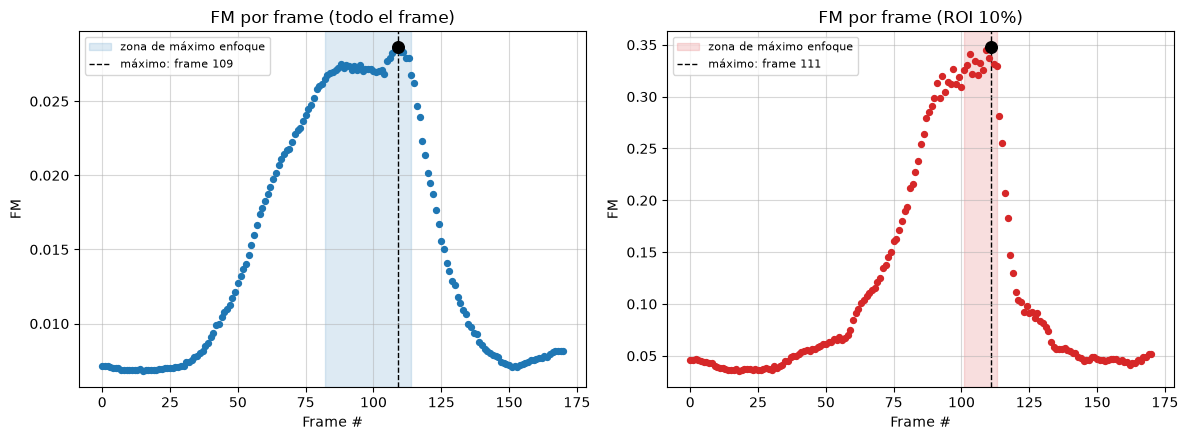

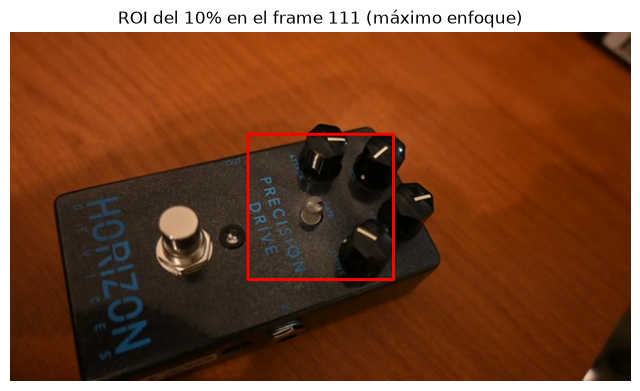

In [6]:
resultado = procesar_video(porcentaje_roi=PORCENTAJE_ROI)
det_full = detectar_maximo_enfoque(resultado["fm_full"])
det_roi = detectar_maximo_enfoque(resultado["fm_roi"])

print(
    f"Punto 1, frame completo: máximo en el frame {det_full['frame_max']} "
    f"(FM = {det_full['fm_max']:.4f}). "
    f"Zona devuelta: frames {det_full['frame_inicio']} a {det_full['frame_fin']}."
)
print(
    f"Punto 2, ROI central ({PORCENTAJE_ROI:.0%} del área): "
    f"máximo en el frame {det_roi['frame_max']} "
    f"(FM = {det_roi['fm_max']:.4f}). "
    f"Zona devuelta: frames {det_roi['frame_inicio']} a {det_roi['frame_fin']}."
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
graficar_fm(
    resultado["frames"],
    resultado["fm_full"],
    det_full,
    "FM por frame (todo el frame)",
    color="tab:blue",
    ax=ax1,
)
graficar_fm(
    resultado["frames"],
    resultado["fm_roi"],
    det_roi,
    f"FM por frame (ROI {PORCENTAJE_ROI:.0%})",
    color="tab:red",
    ax=ax2,
)
plt.tight_layout()
plt.show()

frame_roi = leer_frame(det_roi["frame_max"])
_, caja_roi = obtener_roi(frame_roi, porcentaje=PORCENTAJE_ROI)
vis_roi = frame_roi.copy()
cv.rectangle(vis_roi, (caja_roi[0], caja_roi[1]), (caja_roi[2] - 1, caja_roi[3] - 1), (0, 0, 255), 2)

plt.figure(figsize=(7, 4))
plt.imshow(cv.cvtColor(vis_roi, cv.COLOR_BGR2RGB))
plt.title(f"ROI del {PORCENTAJE_ROI:.0%} en el frame {det_roi['frame_max']} (máximo enfoque)")
plt.axis("off")
plt.tight_layout()
plt.show()

### Matriz de puntos de enfoque

Además del máximo, armamos una matriz en la imagen, medimos los FM en cada punto y **devolvemos los puntos de máximo enfoque**: los cuadrados cuya métrica queda al lado del máximo de esa matriz.

En la imagen, todos los puntos se dibujan en verde y los devueltos por el detector en amarillo. La curva es el FM medio de la matriz, con el frame de máximo enfoque marcado.

Matriz 7x7: máximo enfoque en el frame 91 (FM medio = 0.812). Zona: frames 86 a 107.
Puntos de máximo enfoque devueltos (5):
  fila 1, columna 3, centro (320, 118), FM = 0.992
  fila 1, columna 5, centro (382, 118), FM = 0.977
  fila 2, columna 3, centro (320, 149), FM = 0.975
  fila 2, columna 5, centro (382, 149), FM = 1.000
  fila 4, columna 0, centro (227, 211), FM = 1.000


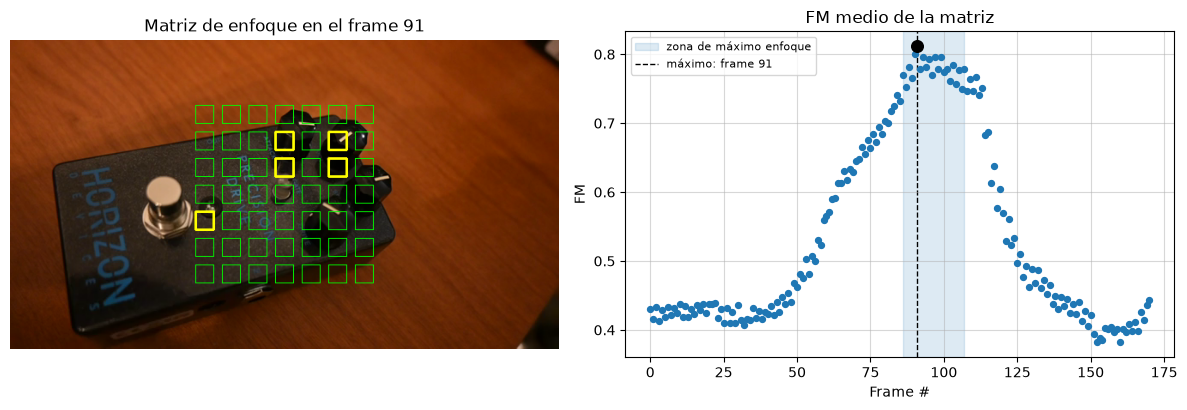

In [7]:
FILAS_MATRIZ = 7
COLUMNAS_MATRIZ = 7
FRACCION_PUNTO_MAX = 0.97


def cajas_matriz_enfoque(alto, ancho, filas=FILAS_MATRIZ, columnas=COLUMNAS_MATRIZ,
                         tamano_caja=22, desplazamiento_caja=31):
    """Matriz centrada de puntos de enfoque. Cada caja es una región donde se mide FM."""
    ancho_caja_x = (columnas - 1) * desplazamiento_caja + tamano_caja
    alto_caja_x = (filas - 1) * desplazamiento_caja + tamano_caja
    
    x0 = (ancho - ancho_caja_x) // 2
    y0 = (alto - alto_caja_x) // 2
    
    cajas = []
    for fila in range(filas):
        for columna in range(columnas):
            x1 = int(x0 + columna * desplazamiento_caja)
            y1 = int(y0 + fila * desplazamiento_caja)
            cajas.append((fila, columna, x1, y1, x1 + tamano_caja, y1 + tamano_caja))
    return cajas


def medir_matriz(imagen_gray, cajas):
    """FM del paper en cada punto de la matriz."""
    return np.array(
        [calcular_FM(imagen_gray[y1:y2, x1:x2]) for _, _, x1, y1, x2, y2 in cajas],
        dtype=np.float64,
    )


def puntos_maximo_enfoque(cajas, valores, fraccion=FRACCION_PUNTO_MAX):
    """Puntos cuya FM está al lado del máximo de la matriz."""
    umbral = float(valores.max()) * fraccion
    puntos = []
    for caja, valor in zip(cajas, valores):
        if valor < umbral:
            continue
        fila, columna, x1, y1, x2, y2 = caja
        puntos.append({
            "fila": int(fila),
            "columna": int(columna),
            "x": int((x1 + x2) // 2),
            "y": int((y1 + y2) // 2),
            "fm": float(valor),
        })
    return puntos


def dibujar_matriz(frame_bgr, cajas, valores=None, fraccion=FRACCION_PUNTO_MAX, umbral=None):
    """Verde: punto medido. Amarillo: punto de máximo enfoque."""
    vis = frame_bgr.copy()
    
    if umbral is None and valores is not None:
        umbral = float(valores.max()) * fraccion
    
    for indice, (_, _, x1, y1, x2, y2) in enumerate(cajas):
        es_maximo = umbral is not None and valores is not None and valores[indice] >= umbral
        color = (0, 255, 255) if es_maximo else (0, 255, 0)
        grosor = 2 if es_maximo else 1
        cv.rectangle(vis, (x1, y1), (x2 - 1, y2 - 1), color, grosor)
    
    return vis


def fm_medio_matriz():
    """FM medio de la matriz, frame a frame."""
    captura = cv.VideoCapture(NOMBRE_VIDEO)
    if not captura.isOpened():
        raise RuntimeError("No se pudo abrir el video")

    serie = []
    cajas = None
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        if cajas is None:
            cajas = cajas_matriz_enfoque(*gray.shape)
        serie.append(float(medir_matriz(gray, cajas).mean()))
    captura.release()
    return np.asarray(serie, dtype=np.float64), cajas


fm_matriz, cajas = fm_medio_matriz()
det_matriz = detectar_maximo_enfoque(fm_matriz)

frame_matriz = leer_frame(det_matriz["frame_max"])
gray_matriz = cv.cvtColor(frame_matriz, cv.COLOR_BGR2GRAY)
valores_puntos = medir_matriz(gray_matriz, cajas)
puntos = puntos_maximo_enfoque(cajas, valores_puntos)
overlay = dibujar_matriz(frame_matriz, cajas, valores_puntos)

print(
    f"Matriz {FILAS_MATRIZ}x{COLUMNAS_MATRIZ}: máximo enfoque en el frame {det_matriz['frame_max']} "
    f"(FM medio = {det_matriz['fm_max']:.3f}). "
    f"Zona: frames {det_matriz['frame_inicio']} a {det_matriz['frame_fin']}."
)
print(f"Puntos de máximo enfoque devueltos ({len(puntos)}):")
for punto in puntos:
    print(
        f"  fila {punto['fila']}, columna {punto['columna']}, "
        f"centro ({punto['x']}, {punto['y']}), FM = {punto['fm']:.3f}"
    )

fig, (ax_img, ax_plot) = plt.subplots(1, 2, figsize=(12, 4.2))
ax_img.imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
ax_img.set_title(f"Matriz de enfoque en el frame {det_matriz['frame_max']}")
ax_img.axis("off")
graficar_fm(
    np.arange(len(fm_matriz)),
    fm_matriz,
    det_matriz,
    "FM medio de la matriz",
    color="tab:blue",
    ax=ax_plot,
)
plt.tight_layout()
plt.show()

### Punto extra: unsharp masking para expandir la zona de enfoque

Sobre el frame de máximo enfoque se aplica unsharp masking (`k = 1`).

Un punto entra en la zona si su FM supera el umbral medido en la imagen original (97% del máximo de la matriz). Con el realce, más puntos cruzan ese mismo umbral: la zona nítida se agranda. La función devuelve la imagen realzada y la lista de puntos de esa zona.

# UNSHARP MASKING

Es un algoritmo que permite **enfocar o mejorar los bordes** mediante un filtro de suavizado.

### Pasos

1. **Desenfoque de la imagen** con un filtro suavizador (ej. Gaussiano):

   $$f(x,y) \rightarrow f_B(x,y)$$

2. **Resta de la imagen original con la suavizada**  
   Sobreviven las componentes de alta frecuencia:

   $$m(x,y) = f(x,y) - f_B(x,y)$$

3. **Agregar esa máscara a la imagen original**  
   Se produce el realce de las componentes de alta frecuencia:

   $$g(x,y) = f(x,y) + k \cdot m(x,y)$$

### De manera genérica

$$g(x,y) = (k+1)\cdot f(x,y) - k\cdot f_B(x,y)$$

Donde:

- **$k = 1$:** Máscara de desenfoque — *Unsharp Masking*
- **$k > 1$:** Filtrado de alto impulso — *High-boost filtering*

### Función de cálculo de Unsharp Mask

In [8]:
def unsharp_mask(image: np.ndarray, k: float = 1.0, blur_kernel_size: tuple = (5, 5), sigma: float = 0) -> np.ndarray:
    """
    Aplica unsharp masking (o filtrado de alto realce si k > 1).

    Retorna imagen realzada (misma forma y tipo que la entrada).
    """
    # Asegurar tipo flotante para evitar saturación en operaciones intermedias
    img = image.astype(np.float32)

    # 1. Desenfoque de la imagen con filtro Gaussiano
    img_blur = cv.GaussianBlur(img, blur_kernel_size, sigmaX=sigma)

    # 2. Máscara de alta frecuencia: m(x,y) = f(x,y) - f_B(x,y)
    mask = img - img_blur

    # 3. Imagen realzada: g(x,y) = f(x,y) + k * m(x,y)
    # Equivalente a: g = (k+1)*f - k*f_B
    img_sharp = img + k * mask

    # Recortar a rango válido y convertir de nuevo al tipo original
    img_sharp = np.clip(img_sharp, 0, 255).astype(image.dtype)

    return img_sharp

Puntos en la zona de enfoque: 5 -> 20 después de unsharp masking.
Zona expandida devuelta: (0,4), (1,1), (1,2), (1,3), (1,4), (1,5), (1,6), (2,1), (2,2), (2,3), (2,5), (2,6), (3,3), (3,4), (3,5), (4,0), (4,4), (4,6), (5,4), (5,5)


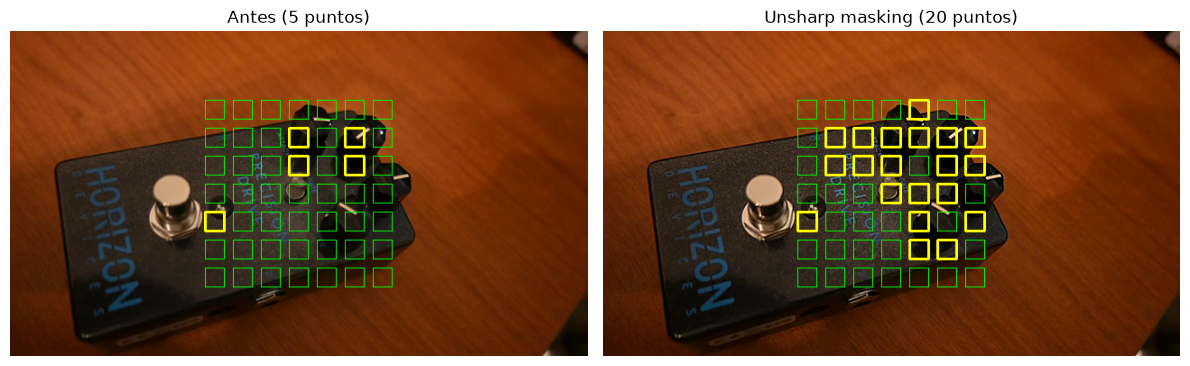

In [9]:
def expandir_zona_enfoque(frame_bgr, cajas, k=1.0, fraccion=FRACCION_PUNTO_MAX):
    """
    Aplica unsharp masking y devuelve la imagen junto con los puntos
    que quedan dentro de la zona de enfoque expandida.

    El umbral es el de la imagen original, así el aumento de puntos
    mide la expansión y no un máximo nuevo.
    """
    gray = cv.cvtColor(frame_bgr, cv.COLOR_BGR2GRAY)
    valores = medir_matriz(gray, cajas)
    umbral = float(valores.max()) * fraccion
    puntos_antes = puntos_maximo_enfoque(cajas, valores, fraccion=fraccion)

    frame_sharp = unsharp_mask(frame_bgr, k=k)
    gray_sharp = cv.cvtColor(frame_sharp, cv.COLOR_BGR2GRAY)
    valores_sharp = medir_matriz(gray_sharp, cajas)

    puntos_expandidos = []
    for caja, valor in zip(cajas, valores_sharp):
        if valor < umbral:
            continue
        fila, columna, x1, y1, x2, y2 = caja
        puntos_expandidos.append({
            "fila": int(fila),
            "columna": int(columna),
            "x": int((x1 + x2) // 2),
            "y": int((y1 + y2) // 2),
            "fm": float(valor),
        })

    overlay_antes = dibujar_matriz(frame_bgr, cajas, valores, umbral=umbral)
    overlay_despues = dibujar_matriz(frame_sharp, cajas, valores_sharp, umbral=umbral)
    return {
        "imagen": frame_sharp,
        "umbral": umbral,
        "puntos_antes": puntos_antes,
        "puntos_expandidos": puntos_expandidos,
        "overlay_antes": overlay_antes,
        "overlay_despues": overlay_despues,
    }


expansion = expandir_zona_enfoque(frame_matriz, cajas, k=1.0)
print(
    f"Puntos en la zona de enfoque: {len(expansion['puntos_antes'])} "
    f"-> {len(expansion['puntos_expandidos'])} después de unsharp masking."
)
print(
    "Zona expandida devuelta: "
    + ", ".join(
        f"({p['fila']},{p['columna']})" for p in expansion["puntos_expandidos"]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].imshow(cv.cvtColor(expansion["overlay_antes"], cv.COLOR_BGR2RGB))
axes[0].set_title(f"Antes ({len(expansion['puntos_antes'])} puntos)")
axes[0].axis("off")
axes[1].imshow(cv.cvtColor(expansion["overlay_despues"], cv.COLOR_BGR2RGB))
axes[1].set_title(f"Unsharp masking ({len(expansion['puntos_expandidos'])} puntos)")
axes[1].axis("off")
plt.tight_layout()
plt.show()